# Component 4 — Banking anomaly: choosing the decision threshold

The champion model in `agency banking.ipynb` (XGBoost) outputs a **probability** that a transaction is anomalous.
To turn it into a yes/no flag, a **threshold** is needed. The original notebook and the ML service used the default
**0.5**. Because the model is trained with `scale_pos_weight` (anomalies weighted ~19×), its probabilities are pushed
up, and at 0.5 it flags far too many normal transactions.

This notebook:
1. loads the **saved** model (`component4_banking_anomaly_model.pkl`, unchanged) and rebuilds the exact same train/test split;
2. picks the threshold using **out-of-fold predictions on the training set only** (the test set is not used for the choice);
3. checks that threshold **once** on the test set;
4. shows the precision / recall / false-alarm trade-off so the choice can be justified.

The original notebook, dataset and `.pkl` are not changed. The chosen value is used by `ml_service/app.py`
(`ANOMALY_THRESHOLD`).

In [1]:
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import (average_precision_score, f1_score, precision_recall_curve,
                             precision_score, recall_score, confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

## 1. Same data and split as `agency banking.ipynb`

In [2]:
bundle = joblib.load('component4_banking_anomaly_model.pkl')
champion = bundle['champion_model']

df = pd.read_csv('paysim.csv').drop_duplicates().reset_index(drop=True)
df = df.drop(columns=['bank_txn_id', 'date'], errors='ignore')
df['is_high_zscore'] = (df['amount_zscore'].abs() > 2.0).astype(int)

y = df['target_anomaly'].astype(int)
X = df.drop(columns=['target_anomaly'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
X_train, X_test = X_train.copy(), X_test.copy()

# Isolation Forest flag, exactly as in training (the saved forest was fitted on the training set)
for part in (X_train, X_test):
    num = bundle['iso_imputer'].transform(part[bundle['iso_num_cols']])
    part['unsupervised_anomaly_score'] = (bundle['iso_forest'].predict(num) == -1).astype(int)

cols = list(champion.feature_names_in_)
print(f'Train: {len(X_train)} | Test: {len(X_test)} | anomaly rate: {y.mean():.3%}')

Train: 131408 | Test: 32852 | anomaly rate: 5.000%


## 2. The problem with 0.5

In [3]:
p_test = champion.predict_proba(X_test[cols])[:, 1]

def summary(y_true, proba, t):
    flag = proba >= t
    tn, fp, fn, tp = confusion_matrix(y_true, flag).ravel()
    return {'threshold': round(float(t), 3),
            'precision': precision_score(y_true, flag), 'recall': recall_score(y_true, flag),
            'f1': f1_score(y_true, flag), 'flagged': int(flag.sum()),
            'false_alarms_per_1000_normal': fp / (fp + tn) * 1000}

s = summary(y_test, p_test, 0.5)
print(f"At 0.5 on the test set: precision {s['precision']:.2f}, recall {s['recall']:.2f}, "
      f"{s['false_alarms_per_1000_normal']:.0f} false alarms per 1000 normal transactions")
print(f"-> of every 100 flagged transactions, about {100 - s['precision'] * 100:.0f} are normal customers.")

At 0.5 on the test set: precision 0.23, recall 0.78, 136 false alarms per 1000 normal transactions
-> of every 100 flagged transactions, about 77 are normal customers.


## 3. Choose the threshold on training data only (out-of-fold)

Each training row gets a probability from a copy of the champion that **did not see that row** (5-fold CV).
The threshold is chosen on these out-of-fold probabilities, so the test set stays untouched.

Criterion: **the threshold with the highest F1** (balance of catching anomalies and not flagging normal
customers). The threshold where precision first reaches 50 % is shown as well.

In [4]:
oof = cross_val_predict(clone(champion), X_train[cols], y_train,
                        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                        method='predict_proba', n_jobs=-1)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best_f1_threshold = float(thr[np.nanargmax(f1[:-1])])
precision50_threshold = float(thr[np.argmax(prec[:-1] >= 0.5)])
CHOSEN = round(best_f1_threshold, 2)

print(f'Out-of-fold PR-AUC           : {average_precision_score(y_train, oof):.3f}')
print(f'Threshold with max F1 (OOF)  : {best_f1_threshold:.3f}')
print(f'Threshold for precision >=50%: {precision50_threshold:.3f}')
print(f'Chosen threshold             : {CHOSEN}')

Out-of-fold PR-AUC           : 0.525
Threshold with max F1 (OOF)  : 0.858
Threshold for precision >=50%: 0.855
Chosen threshold             : 0.86


## 4. Check once on the test set

In [5]:
rows = []
for t in sorted({0.5, CHOSEN, 0.9, 0.95}):
    tr = summary(y_train, oof, t); te = summary(y_test, p_test, t)
    rows.append({'threshold': t,
                 'train OOF precision': tr['precision'], 'train OOF recall': tr['recall'], 'train OOF F1': tr['f1'],
                 'TEST precision': te['precision'], 'TEST recall': te['recall'], 'TEST F1': te['f1'],
                 'TEST false alarms / 1000 normal': te['false_alarms_per_1000_normal']})
table = pd.DataFrame(rows).set_index('threshold')
table.round(2)

,train OOF precision,train OOF recall,train OOF F1,TEST precision,TEST recall,TEST F1,TEST false alarms / 1000 normal
threshold,,,,,,,
0.50,0.23,0.79,0.35,0.23,0.78,0.36,136.27
0.86,0.51,0.44,0.48,0.51,0.42,0.46,21.15
0.90,0.61,0.37,0.46,0.59,0.35,0.44,12.88
0.95,0.82,0.25,0.39,0.85,0.25,0.39,2.34


The out-of-fold and test numbers agree closely, so the chosen threshold generalises.

Compared with 0.5, the chosen threshold cuts false alarms by roughly **6×** (about 136 → 22 per 1000 normal
transactions) and doubles precision (0.23 → ~0.50), at the cost of recall (0.78 → ~0.43).
For an agent, a flag is a request to double-check a customer, so fewer false alarms makes the flags usable.
The CBSL amount rule in the backend still flags any transaction at or over the daily limit, independent of the model.

## 5. Precision / recall trade-off chart

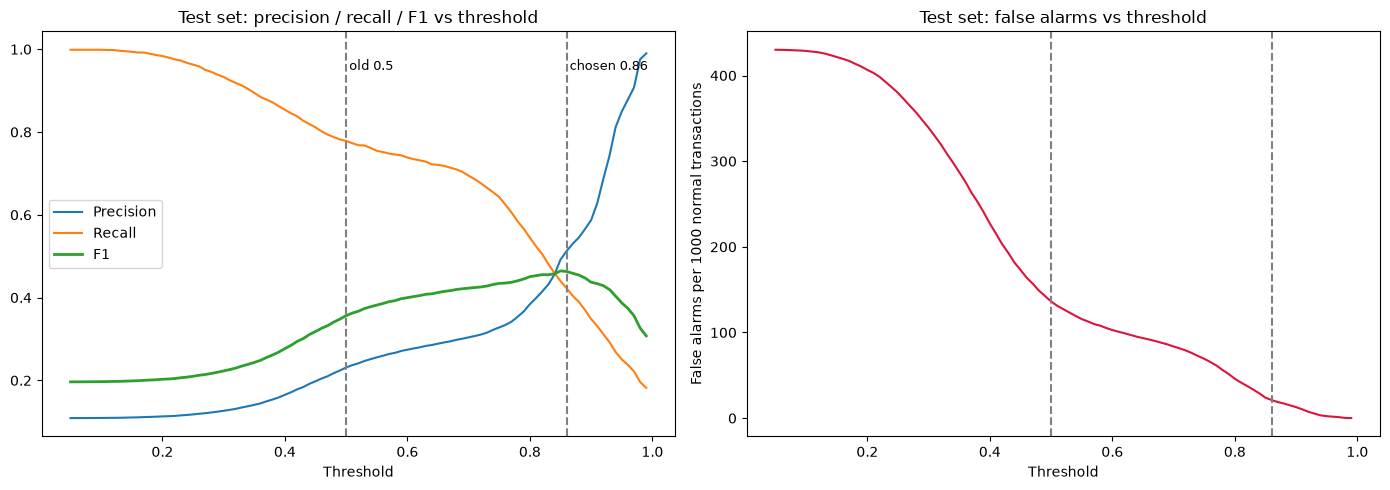

In [6]:
ts = np.linspace(0.05, 0.99, 95)
curve = pd.DataFrame([summary(y_test, p_test, t) for t in ts])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(curve['threshold'], curve['precision'], label='Precision')
axes[0].plot(curve['threshold'], curve['recall'], label='Recall')
axes[0].plot(curve['threshold'], curve['f1'], label='F1', lw=2)
for t, lbl in [(0.5, 'old 0.5'), (CHOSEN, f'chosen {CHOSEN}')]:
    axes[0].axvline(t, ls='--', color='grey'); axes[0].text(t + 0.005, 0.95, lbl, fontsize=9)
axes[0].set_xlabel('Threshold'); axes[0].set_title('Test set: precision / recall / F1 vs threshold'); axes[0].legend()

axes[1].plot(curve['threshold'], curve['false_alarms_per_1000_normal'], color='crimson')
axes[1].axvline(0.5, ls='--', color='grey'); axes[1].axvline(CHOSEN, ls='--', color='grey')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('False alarms per 1000 normal transactions')
axes[1].set_title('Test set: false alarms vs threshold')
plt.tight_layout(); plt.savefig('component4_threshold.png', dpi=120); plt.show()

## 6. Where anomalies occur (important for the app)

In [7]:
rate = pd.Series(y.values, index=X['txn_type'].values).groupby(level=0).agg(['mean', 'size'])
rate.columns = ['anomaly rate', 'rows']
rate.sort_values('anomaly rate', ascending=False).round(3)

,anomaly rate,rows
transfer,0.24,17059
cash_out,0.07,58723
cash_in,0.00,34663
debit,0.00,989
payment,0.00,52826


Anomalies in this dataset exist only for **cash_out** and **transfer**. The app maps a cash **deposit** to
`cash_in`, so the model will practically never flag a deposit; deposits are covered only by the CBSL amount rule.
This limitation of the dataset should be stated in the thesis.

In [8]:
print(f'Use in ml_service/app.py:  ANOMALY_THRESHOLD = {CHOSEN}')

Use in ml_service/app.py:  ANOMALY_THRESHOLD = 0.86
